# Low-Rank Covariance Updates: Why $\Sigma_{new} = \Sigma + XX^T$?

This notebook explains step-by-step why we update a covariance matrix using the formula $\Sigma_{new} = \Sigma + XX^T$, which is fundamental to understanding the Matrix Inversion Lemma.

```{note}
This notebook provides a detailed explanation of the covariance update used in the [Matrix Inversion Lemma: Gene Regulatory Network Inference](7-3-matrix_inversion_lemma_grn.ipynb) notebook.
```

## 1. The Setup: What Does $XX^T$ Actually Mean?

Let's start with a concrete example. Suppose we have:
- $N = 4$ genes whose expression we're measuring
- $D = 2$ newly discovered transcription factor (TF) pathways

The matrix $X$ has shape $(N \times D)$, where each column represents a **TF pathway** and each row represents how strongly a **gene** responds to that pathway.

In [24]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

In [25]:
# 4 genes, 2 new TF pathways
genes = ['TP53', 'BRCA1', 'IL6', 'TNF']
pathways = ['p53 Pathway', 'NF-κB Pathway']

# X matrix: how much each gene responds to each TF pathway
# Rows = genes, Columns = TF pathways
X = np.array([
    [0.8, 0.1],   # TP53: high p53 response, low NF-κB
    [0.7, 0.1],   # BRCA1: high p53 response, low NF-κB
    [0.1, 0.9],   # IL6: low p53, high NF-κB response
    [0.1, 0.8],   # TNF: low p53, high NF-κB response
])

print("TF Pathway Loading Matrix X (N×D = 4×2):")
print("=" * 45)
print(f"{'Gene':<12} {'p53 Pathway':>12} {'NF-κB':>12}")
print("-" * 45)
for i, gene in enumerate(genes):
    print(f"{gene:<12} {X[i, 0]:>12.1f} {X[i, 1]:>12.1f}")

TF Pathway Loading Matrix X (N×D = 4×2):
Gene          p53 Pathway        NF-κB
---------------------------------------------
TP53                  0.8          0.1
BRCA1                 0.7          0.1
IL6                   0.1          0.9
TNF                   0.1          0.8


## 2. What is $XX^T$? The Outer Product Expansion

The key insight is that $XX^T$ can be written as a **sum of outer products**:

$$XX^T = \sum_{k=1}^{D} x_k x_k^T$$

where $x_k$ is the $k$-th column of $X$ (the loadings for TF pathway $k$).

**Why?** Write $X$ in terms of its columns: $X = [x_1 \mid x_2 \mid \cdots \mid x_D]$. Then matrix multiplication is just "row of the left times column of the right". But here the left matrix is $X$ and the right is $X^T$, whose columns are the *rows* of $X$... There's a simpler way to see it. Each column $x_k$ is an $N \times 1$ vector, so $X^T$ stacks them as rows:

$$X^T = \begin{bmatrix} — x_1^T — \\ — x_2^T — \\ \vdots \\ — x_D^T — \end{bmatrix}$$

Now multiply:

$$XX^T = [x_1 \mid x_2 \mid \cdots \mid x_D] \begin{bmatrix} — x_1^T — \\ — x_2^T — \\ \vdots \\ — x_D^T — \end{bmatrix} = x_1 x_1^T + x_2 x_2^T + \cdots + x_D x_D^T$$

This follows directly from the **column-row expansion** of matrix multiplication: if $A = [a_1 \mid \cdots \mid a_D]$ and $B$ has rows $b_k^T$, then $AB = \sum_k a_k b_k^T$. Here $A = X$ and $B = X^T$, so $a_k = x_k$ and $b_k^T = x_k^T$, giving us the result.

Each term $x_k x_k^T$ is an $N \times N$ **rank-1** matrix that captures the **co-expression contribution from TF pathway $k$** alone.

In [26]:
# Extract individual pathway columns
x_p53 = X[:, 0]   # p53 pathway loadings
x_nfkb = X[:, 1]  # NF-κB pathway loadings

print("Pathway 1 (p53) loadings:")
for i, gene in enumerate(genes):
    print(f"  {gene}: {x_p53[i]:.1f}")

print("\nPathway 2 (NF-κB) loadings:")
for i, gene in enumerate(genes):
    print(f"  {gene}: {x_nfkb[i]:.1f}")

Pathway 1 (p53) loadings:
  TP53: 0.8
  BRCA1: 0.7
  IL6: 0.1
  TNF: 0.1

Pathway 2 (NF-κB) loadings:
  TP53: 0.1
  BRCA1: 0.1
  IL6: 0.9
  TNF: 0.8


In [27]:
# Compute outer products for each pathway
outer_p53 = np.outer(x_p53, x_p53)    # x_1 @ x_1^T
outer_nfkb = np.outer(x_nfkb, x_nfkb)  # x_2 @ x_2^T

# Sum of outer products
sum_outer = outer_p53 + outer_nfkb

# Direct computation
XXT = X @ X.T

print("Verification: XX^T = x_p53 @ x_p53^T + x_nfkb @ x_nfkb^T")
print(f"Are they equal? {np.allclose(XXT, sum_outer)}")

Verification: XX^T = x_p53 @ x_p53^T + x_nfkb @ x_nfkb^T
Are they equal? True


## 3. Visualizing Each Pathway's Contribution

Let's see what each outer product looks like:

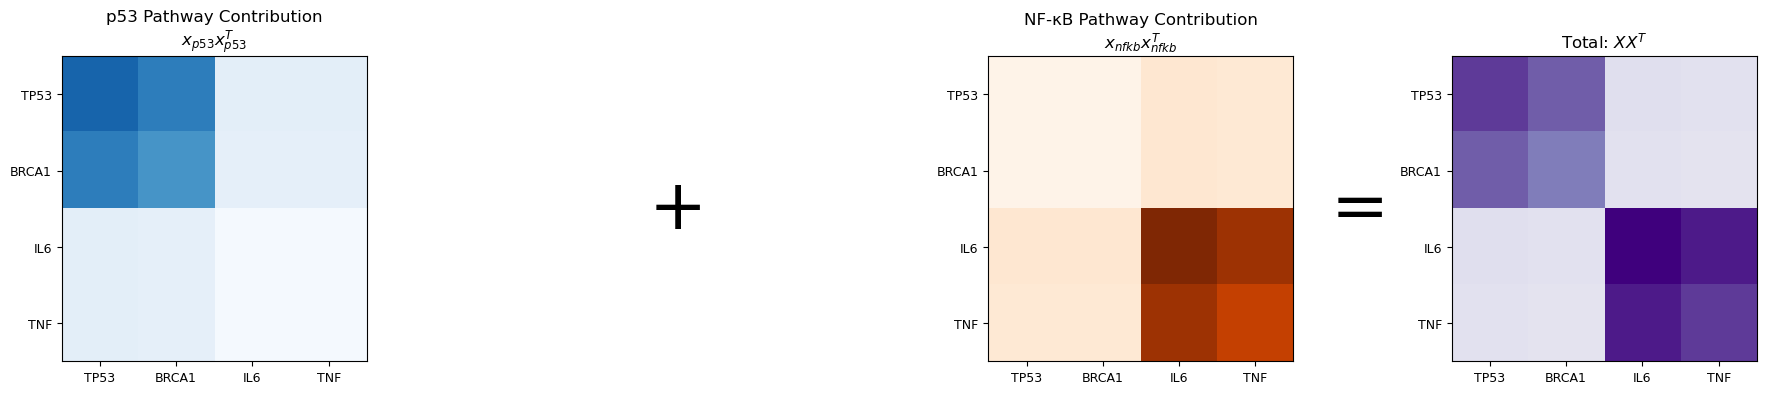

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Plot p53 pathway contribution
im0 = axes[0].imshow(outer_p53, cmap='Blues', vmin=0, vmax=0.8)
axes[0].set_title('p53 Pathway Contribution\n$x_{p53} x_{p53}^T$', fontsize=12)

# Plus sign
axes[1].text(0.5, 0.5, '+', fontsize=50, ha='center', va='center')
axes[1].axis('off')

# Plot NF-κB pathway contribution
im2 = axes[2].imshow(outer_nfkb, cmap='Oranges', vmin=0, vmax=0.8)
axes[2].set_title('NF-κB Pathway Contribution\n$x_{nfkb} x_{nfkb}^T$', fontsize=12)

# Equals sign and sum
axes[3].text(-0.3, 0.5, '=', fontsize=50, ha='center', va='center', transform=axes[3].transAxes)
im3 = axes[3].imshow(sum_outer, cmap='Purples', vmin=0, vmax=0.8)
axes[3].set_title('Total: $XX^T$', fontsize=12)

for ax in [axes[0], axes[2], axes[3]]:
    ax.set_xticks(range(4))
    ax.set_xticklabels(genes, fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels(genes, fontsize=9)

plt.tight_layout()
plt.show()

In [29]:
# Show the matrices with values
def print_matrix(mat, title, genes):
    print(f"\n{title}")
    print("=" * 50)
    print(f"{'':12}", end='')
    for gene in genes:
        print(f"{gene:>10}", end='')
    print()
    print("-" * 50)
    for i, gene in enumerate(genes):
        print(f"{gene:<12}", end='')
        for j in range(len(genes)):
            print(f"{mat[i, j]:>10.2f}", end='')
        print()

print_matrix(outer_p53, "p53 Pathway: x_p53 @ x_p53^T", genes)
print_matrix(outer_nfkb, "NF-κB Pathway: x_nfkb @ x_nfkb^T", genes)
print_matrix(XXT, "Total: XX^T", genes)


p53 Pathway: x_p53 @ x_p53^T
                  TP53     BRCA1       IL6       TNF
--------------------------------------------------
TP53              0.64      0.56      0.08      0.08
BRCA1             0.56      0.49      0.07      0.07
IL6               0.08      0.07      0.01      0.01
TNF               0.08      0.07      0.01      0.01

NF-κB Pathway: x_nfkb @ x_nfkb^T
                  TP53     BRCA1       IL6       TNF
--------------------------------------------------
TP53              0.01      0.01      0.09      0.08
BRCA1             0.01      0.01      0.09      0.08
IL6               0.09      0.09      0.81      0.72
TNF               0.08      0.08      0.72      0.64

Total: XX^T
                  TP53     BRCA1       IL6       TNF
--------------------------------------------------
TP53              0.65      0.57      0.17      0.16
BRCA1             0.57      0.50      0.16      0.15
IL6               0.17      0.16      0.82      0.73
TNF               0.16      

## 4. The Key Insight: Why Does This Represent Covariance?

### The Factor Model for Gene Expression

In genomics, we model gene expression levels as:

$$g_i = \sum_{k=1}^{D} x_{ik} \cdot f_k + \epsilon_i$$

Where:
- $g_i$ = expression level of gene $i$
- $x_{ik}$ = loading of gene $i$ on TF pathway $k$ (from matrix $X$)
- $f_k$ = activity of TF pathway $k$ (e.g., "p53 pathway activated strongly in this sample")
- $\epsilon_i$ = gene-specific noise (stochastic expression, measurement error)

### Computing Covariance

The covariance between genes $i$ and $j$ due to TF pathway $k$ is:

$$\text{Cov}(g_i, g_j) \text{ from pathway } k = x_{ik} \cdot x_{jk} \cdot \text{Var}(f_k)$$

If we assume $\text{Var}(f_k) = 1$ for all pathways, then:

$$\text{Cov}(g_i, g_j) = \sum_{k=1}^{D} x_{ik} \cdot x_{jk} = (XX^T)_{ij}$$

**This is exactly what $XX^T$ computes!**

In [30]:
# Let's verify with a concrete example
# Covariance between TP53 (i=0) and BRCA1 (j=1)

i, j = 0, 1  # TP53 and BRCA1

# Manual calculation
cov_from_p53 = X[i, 0] * X[j, 0]    # Both regulated by p53
cov_from_nfkb = X[i, 1] * X[j, 1]   # Both respond to NF-κB
total_cov_manual = cov_from_p53 + cov_from_nfkb

# From XX^T
total_cov_matrix = XXT[i, j]

print(f"Covariance between {genes[i]} and {genes[j]}:")
print("=" * 50)
print(f"\nFrom p53 pathway:  {X[i,0]:.1f} x {X[j,0]:.1f} = {cov_from_p53:.2f}")
print(f"From NF-κB pathway: {X[i,1]:.1f} x {X[j,1]:.1f} = {cov_from_nfkb:.2f}")
print(f"                              ---------")
print(f"Total (manual):                  {total_cov_manual:.2f}")
print(f"From XX^T:                       {total_cov_matrix:.2f}")
print(f"\nThey match!")

Covariance between TP53 and BRCA1:

From p53 pathway:  0.8 x 0.7 = 0.56
From NF-κB pathway: 0.1 x 0.1 = 0.01
                              ---------
Total (manual):                  0.57
From XX^T:                       0.57

They match!


In [31]:
# Now let's compare TP53-BRCA1 vs TP53-IL6
print("Why TP53-BRCA1 covariance is HIGH:")
print("-" * 50)
print(f"  TP53 p53 loading:  {X[0, 0]:.1f}")
print(f"  BRCA1 p53 loading: {X[1, 0]:.1f}")
print(f"  -> p53 contribution: {X[0,0]:.1f} x {X[1,0]:.1f} = {X[0,0]*X[1,0]:.2f}")
print(f"  Total covariance: {XXT[0,1]:.2f}")

print("\nWhy TP53-IL6 covariance is LOW:")
print("-" * 50)
print(f"  TP53 p53 loading: {X[0, 0]:.1f}  |  IL6 p53 loading: {X[2, 0]:.1f}")
print(f"  TP53 NF-κB loading: {X[0, 1]:.1f}  |  IL6 NF-κB loading: {X[2, 1]:.1f}")
print(f"  -> p53 contribution:  {X[0,0]:.1f} x {X[2,0]:.1f} = {X[0,0]*X[2,0]:.2f}")
print(f"  -> NF-κB contribution: {X[0,1]:.1f} x {X[2,1]:.1f} = {X[0,1]*X[2,1]:.2f}")
print(f"  Total covariance: {XXT[0,2]:.2f}")

print("\nKey insight: Genes regulated by the SAME pathway have HIGH covariance!")

Why TP53-BRCA1 covariance is HIGH:
--------------------------------------------------
  TP53 p53 loading:  0.8
  BRCA1 p53 loading: 0.7
  -> p53 contribution: 0.8 x 0.7 = 0.56
  Total covariance: 0.57

Why TP53-IL6 covariance is LOW:
--------------------------------------------------
  TP53 p53 loading: 0.8  |  IL6 p53 loading: 0.1
  TP53 NF-κB loading: 0.1  |  IL6 NF-κB loading: 0.9
  -> p53 contribution:  0.8 x 0.1 = 0.08
  -> NF-κB contribution: 0.1 x 0.9 = 0.09
  Total covariance: 0.17

Key insight: Genes regulated by the SAME pathway have HIGH covariance!


## 5. Why ADD $XX^T$ to an Existing Covariance?

Now we understand what $XX^T$ represents. But why do we **add** it to an existing $\Sigma$?

### Scenario: New Pathways Discovered

Imagine you have:
1. **Baseline covariance** $\Sigma$: Based on previous RNA-seq experiments (gene-specific noise only)
2. **Newly discovered TF pathways** $X$: Representing regulatory programs just identified in new studies

The new pathways add **additional sources of co-expression** on top of existing patterns:

$$\Sigma_{new} = \underbrace{\Sigma}_{\text{baseline}} + \underbrace{XX^T}_{\text{new pathway effects}}$$

In [32]:
# Create a simple baseline covariance (diagonal = independent genes)
baseline_var = np.array([0.04, 0.03, 0.05, 0.06])  # Individual expression variances
Sigma_baseline = np.diag(baseline_var)

print("Baseline Covariance Sigma (genes are independent):")
print_matrix(Sigma_baseline, "", genes)

print("\nInterpretation: Before discovering the TF pathways,")
print("   these genes appeared to vary independently")
print("   (off-diagonal = 0 means no co-expression)")

Baseline Covariance Sigma (genes are independent):


                  TP53     BRCA1       IL6       TNF
--------------------------------------------------
TP53              0.04      0.00      0.00      0.00
BRCA1             0.00      0.03      0.00      0.00
IL6               0.00      0.00      0.05      0.00
TNF               0.00      0.00      0.00      0.06

Interpretation: Before discovering the TF pathways,
   these genes appeared to vary independently
   (off-diagonal = 0 means no co-expression)


In [33]:
# Now add the new TF pathway structure
Sigma_new = Sigma_baseline + XXT

print("Updated Covariance Sigma_new = Sigma + XX^T:")
print_matrix(Sigma_new, "", genes)

print("\nInterpretation:")
print(f"   TP53-BRCA1 now co-expressed: {Sigma_new[0,1]:.2f} (both regulated by p53)")
print(f"   IL6-TNF now co-expressed: {Sigma_new[2,3]:.2f} (both regulated by NF-κB)")
print(f"   TP53-IL6 still low: {Sigma_new[0,2]:.2f} (different pathways)")

Updated Covariance Sigma_new = Sigma + XX^T:


                  TP53     BRCA1       IL6       TNF
--------------------------------------------------
TP53              0.69      0.57      0.17      0.16
BRCA1             0.57      0.53      0.16      0.15
IL6               0.17      0.16      0.87      0.73
TNF               0.16      0.15      0.73      0.71

Interpretation:
   TP53-BRCA1 now co-expressed: 0.57 (both regulated by p53)
   IL6-TNF now co-expressed: 0.73 (both regulated by NF-κB)
   TP53-IL6 still low: 0.17 (different pathways)


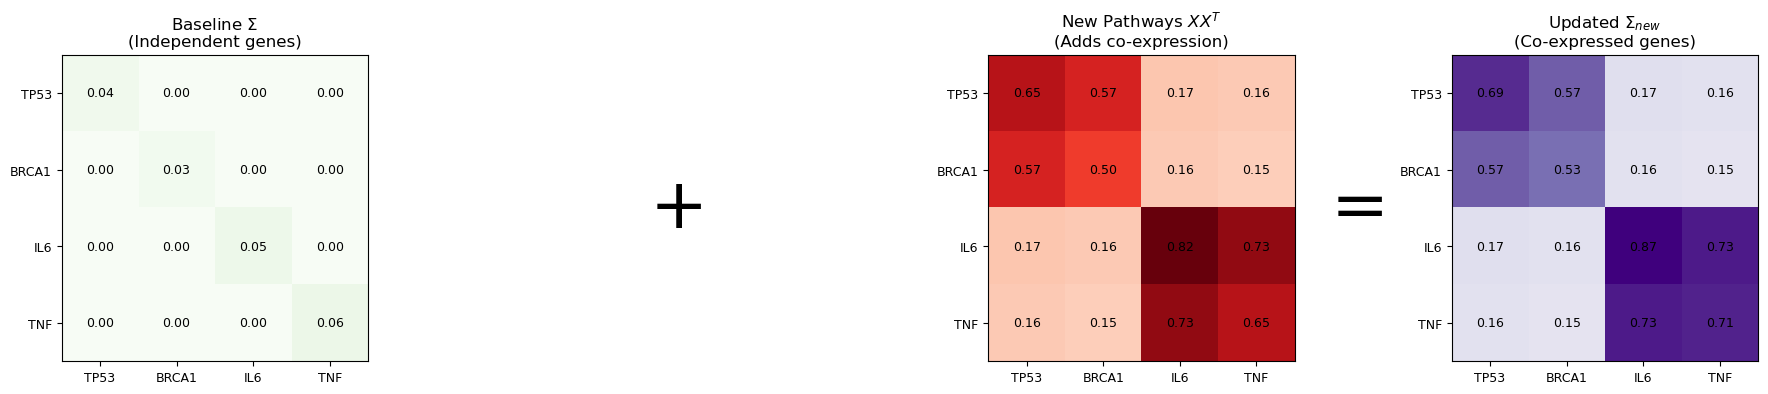

In [34]:
# Visualize the update
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Baseline
im0 = axes[0].imshow(Sigma_baseline, cmap='Greens', vmin=0, vmax=0.8)
axes[0].set_title('Baseline $\\Sigma$\n(Independent genes)', fontsize=12)

# Plus
axes[1].text(0.5, 0.5, '+', fontsize=50, ha='center', va='center')
axes[1].axis('off')

# XX^T
im2 = axes[2].imshow(XXT, cmap='Reds', vmin=0, vmax=0.8)
axes[2].set_title('New Pathways $XX^T$\n(Adds co-expression)', fontsize=12)

# Result
axes[3].text(-0.3, 0.5, '=', fontsize=50, ha='center', va='center', transform=axes[3].transAxes)
im3 = axes[3].imshow(Sigma_new, cmap='Purples', vmin=0, vmax=0.8)
axes[3].set_title('Updated $\\Sigma_{new}$\n(Co-expressed genes)', fontsize=12)

for ax in [axes[0], axes[2], axes[3]]:
    ax.set_xticks(range(4))
    ax.set_xticklabels(genes, fontsize=9)
    ax.set_yticks(range(4))
    ax.set_yticklabels(genes, fontsize=9)
    
    # Add values
    mat = [Sigma_baseline, None, XXT, Sigma_new][[axes[0], axes[1], axes[2], axes[3]].index(ax)]
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Mathematical Properties: Why This Works

### Property 1: $XX^T$ is Always Positive Semi-Definite

For any vector $v$:
$$v^T (XX^T) v = (X^T v)^T (X^T v) = \|X^T v\|^2 \geq 0$$

This means $XX^T$ can only **add** variance, never subtract it. Biologically, discovering a new regulatory pathway can only *explain more* co-expression — it cannot make genes less variable.

In [35]:
# Verify XX^T is positive semi-definite
eigenvalues_XXT = np.linalg.eigvalsh(XXT)

print("Eigenvalues of XX^T:")
print(eigenvalues_XXT)
print(f"\nAll eigenvalues ≥ 0? {all(eigenvalues_XXT >= -1e-10)}")
print("\n✓ XX^T is positive semi-definite!")

Eigenvalues of XX^T:
[-0.     0.     0.952  1.668]

All eigenvalues ≥ 0? True

✓ XX^T is positive semi-definite!


### Property 2: Sum of PSD Matrices is PSD

If $\Sigma$ is positive definite (valid covariance) and $XX^T$ is positive semi-definite, then:

$$\Sigma_{new} = \Sigma + XX^T \text{ is also positive definite}$$

This guarantees the updated covariance is still a valid covariance matrix — a crucial requirement for downstream analyses like computing the precision matrix for gene regulatory network inference.

In [36]:
# Verify Sigma_new is positive definite
eigenvalues_new = np.linalg.eigvalsh(Sigma_new)

print("Eigenvalues of Σ_new:")
print(eigenvalues_new)
print(f"\nAll eigenvalues > 0? {all(eigenvalues_new > 0)}")
print("\n✓ Σ_new is positive definite (valid covariance matrix)!")

Eigenvalues of Σ_new:
[0.034 0.056 0.993 1.717]

All eigenvalues > 0? True

✓ Σ_new is positive definite (valid covariance matrix)!


### Property 3: $XX^T$ is Low-Rank

If $X$ is $N \times D$ with $D < N$, then $XX^T$ has rank at most $D$.

This is why it's called a **low-rank update** — we're adding a matrix with only $D$ non-zero eigenvalues. In our context, $D$ is the number of newly discovered TF pathways (a handful), while $N$ is the number of genes (hundreds or thousands).

In [37]:
# Check the rank
N, D = X.shape
rank_XXT = np.linalg.matrix_rank(XXT)

print(f"X shape: {N} × {D}")
print(f"XX^T shape: {N} × {N}")
print(f"Rank of XX^T: {rank_XXT}")
print(f"\n✓ Rank = D = {D} (low-rank!)")

print(f"\nEigenvalues of XX^T: {eigenvalues_XXT}")
print(f"Number of non-zero eigenvalues: {np.sum(eigenvalues_XXT > 1e-10)}")

X shape: 4 × 2
XX^T shape: 4 × 4
Rank of XX^T: 2

✓ Rank = D = 2 (low-rank!)

Eigenvalues of XX^T: [-0.     0.     0.952  1.668]
Number of non-zero eigenvalues: 2


## 7. Real-World Example: Adding Biological Perturbations

Let's simulate a realistic scenario with more genes across different functional groups:

In [38]:
# Larger example: 100 genes, 3 new perturbation-induced pathways
N_large = 100
D_large = 3

perturbation_names = ['Chemotherapy Stress', 'Immune Activation', 'Growth Factor Stimulation']

# Create structured exposures based on gene functional groups
np.random.seed(123)

# Chemotherapy stress: activates DNA damage response in all genes somewhat
x_chemo = np.random.uniform(0.2, 0.5, N_large)

# Immune activation: strongly affects immune genes (first 30) and cytokine genes (next 20)
x_immune = np.zeros(N_large)
x_immune[:30] = np.random.uniform(0.5, 0.8, 30)   # Immune genes
x_immune[30:50] = np.random.uniform(0.4, 0.7, 20)  # Cytokine genes
x_immune[50:] = np.random.uniform(0.0, 0.2, 50)    # Others

# Growth factor stimulation: strongly affects proliferation genes (last 40)
x_growth = np.zeros(N_large)
x_growth[60:] = np.random.uniform(0.5, 0.9, 40)  # Proliferation / signaling genes
x_growth[:60] = np.random.uniform(0.0, 0.2, 60)  # Others

X_large = np.column_stack([x_chemo, x_immune, x_growth])

print(f"Pathway loading matrix shape: {X_large.shape}")
print(f"\nMean loadings by gene functional group:")
print(f"  {'Group':<20} {'Chemo Stress':>14} {'Immune Act.':>14} {'Growth Factor':>14}")
print(f"  {'-'*62}")
print(f"  {'Immune genes':<20} {X_large[:30, 0].mean():>14.2f} {X_large[:30, 1].mean():>14.2f} {X_large[:30, 2].mean():>14.2f}")
print(f"  {'Cytokine genes':<20} {X_large[30:50, 0].mean():>14.2f} {X_large[30:50, 1].mean():>14.2f} {X_large[30:50, 2].mean():>14.2f}")
print(f"  {'Metabolic genes':<20} {X_large[50:60, 0].mean():>14.2f} {X_large[50:60, 1].mean():>14.2f} {X_large[50:60, 2].mean():>14.2f}")
print(f"  {'Proliferation genes':<20} {X_large[60:, 0].mean():>14.2f} {X_large[60:, 1].mean():>14.2f} {X_large[60:, 2].mean():>14.2f}")

Pathway loading matrix shape: (100, 3)

Mean loadings by gene functional group:
  Group                  Chemo Stress    Immune Act.  Growth Factor
  --------------------------------------------------------------
  Immune genes                   0.35           0.66           0.09
  Cytokine genes                 0.35           0.56           0.09
  Metabolic genes                0.36           0.10           0.12
  Proliferation genes            0.35           0.10           0.70


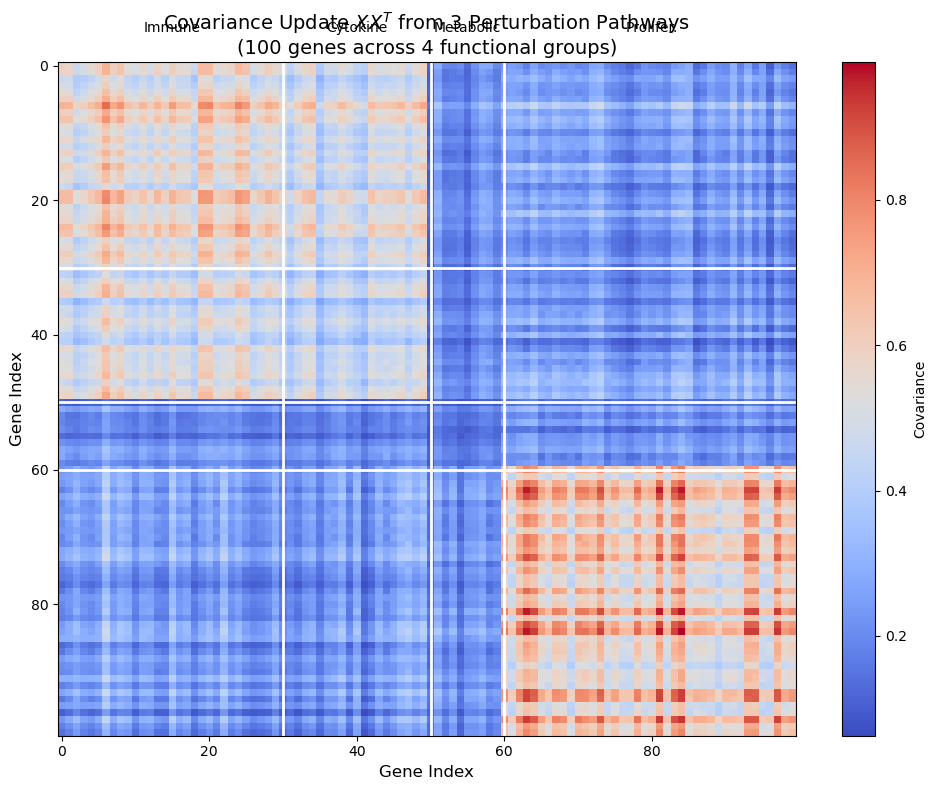


Block structure shows functional group co-expression:
   Immune-Immune: High (shared immune activation response)
   Proliferation-Proliferation: High (shared growth factor response)
   All-All: Moderate (chemotherapy stress affects everyone)


In [39]:
# Compute the covariance update
XXT_large = X_large @ X_large.T

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(XXT_large, cmap='coolwarm', aspect='auto')

# Add functional group boundaries
ax.axhline(30, color='white', linewidth=2)
ax.axhline(50, color='white', linewidth=2)
ax.axhline(60, color='white', linewidth=2)
ax.axvline(30, color='white', linewidth=2)
ax.axvline(50, color='white', linewidth=2)
ax.axvline(60, color='white', linewidth=2)

ax.set_title('Covariance Update $XX^T$ from 3 Perturbation Pathways\n(100 genes across 4 functional groups)', fontsize=14)
ax.set_xlabel('Gene Index', fontsize=12)
ax.set_ylabel('Gene Index', fontsize=12)

# Group annotations
ax.text(15, -5, 'Immune', ha='center', fontsize=10)
ax.text(40, -5, 'Cytokine', ha='center', fontsize=10)
ax.text(55, -5, 'Metabolic', ha='center', fontsize=10)
ax.text(80, -5, 'Prolifer.', ha='center', fontsize=10)

plt.colorbar(im, label='Covariance')
plt.tight_layout()
plt.show()

print("\nBlock structure shows functional group co-expression:")
print("   Immune-Immune: High (shared immune activation response)")
print("   Proliferation-Proliferation: High (shared growth factor response)")
print("   All-All: Moderate (chemotherapy stress affects everyone)")

## 8. Summary

### Why $\Sigma_{new} = \Sigma + XX^T$?

| Aspect | Explanation |
|--------|-------------|
| **What is $X$?** | TF pathway loading matrix $(N \times D)$: how each gene responds to each pathway |
| **What is $XX^T$?** | Co-expression covariance from shared pathways: $(XX^T)_{ij} = \sum_k x_{ik} x_{jk}$ |
| **Why add?** | Newly discovered pathways add **additional** co-expression on top of existing patterns |
| **Why valid?** | Sum of PSD matrices is PSD — result is a valid covariance matrix |
| **Why "low-rank"?** | $XX^T$ has rank $D \ll N$ — efficient to compute and invert |

### Key Formulas

1. **Factor model**: $g_i = \sum_k x_{ik} f_k + \epsilon_i$

2. **Co-expression from shared pathways**: $\text{Cov}(g_i, g_j) = \sum_k x_{ik} x_{jk} = (XX^T)_{ij}$

3. **Covariance update**: $\Sigma_{new} = \Sigma + XX^T$

4. **Efficient inverse** (Matrix Inversion Lemma):
   $$(\Sigma + XX^T)^{-1} = \Sigma^{-1} - \Sigma^{-1}X(I + X^T\Sigma^{-1}X)^{-1}X^T\Sigma^{-1}$$